# Guía práctica: PLN con Deep Learning — De los textos a la clasificación

- Autor: Marlon Cárdenas
- Asignatura: IA-II

**Tipo:** Guía didáctica

## ¿Qué aprenderás?

| Parte | Tema | Herramienta |
|-------|------|-------------|
| 1 | Preprocesamiento de texto | sklearn, re, collections |
| 2 | Embeddings Skip-Gram desde cero | Keras (Embedding, Dot, Dense) |
| 3 | Clasificación con LSTM y GRU | Keras (LSTM, GRU, pad_sequences) |
| 4 | Evaluación con matriz de confusión | sklearn (ConfusionMatrixDisplay) |

**Dataset de ejemplo:** 20 Newsgroups (sklearn) — un corpus real de foros de discusión.

> **Importante:** Todos los hiperparámetros se definen como variables con nombre.


## Configuración e imports

Cargamos todas las librerías necesarias de una vez. La tabla anterior explica para qué sirve cada una.


In [1]:
import numpy as np
import re
import collections
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

# Datos
from sklearn.datasets import fetch_20newsgroups

# Preprocesamiento y evaluación
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# Reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

print(f'TensorFlow {tf.__version__}')
print(f'NumPy      {np.__version__}')


TensorFlow 2.21.0
NumPy      2.4.4


# PARTE 1 — Preprocesamiento de texto

## 1.1 Cargar el dataset

Usamos **20 Newsgroups**, un dataset clásico de clasificación de texto con
mensajes de foros organizados en categorías temáticas.

Para que el cuaderno sea rápido, seleccionamos solo **4 categorías**:

| Categoría | Tema |
|-----------|------|
| `sci.space` | Ciencia espacial |
| `rec.sport.baseball` | Deportes (béisbol) |
| `comp.graphics` | Informática (gráficos) |
| `talk.politics.mideast` | Política (Medio Oriente) |

Estas 4 categorías son lo bastante diferentes para que un clasificador
pueda distinguirlas, pero lo bastante complejas para que no sea trivial.


In [2]:
# Categorías seleccionadas (4 de las 20 disponibles)
CATEGORIAS = ['sci.space', 'rec.sport.baseball',
              'comp.graphics', 'talk.politics.mideast']

# Cargar datos de entrenamiento y test
datos_train = fetch_20newsgroups(subset='train', categories=CATEGORIAS,
                                  remove=('headers','footers','quotes'),
                                  random_state=42)
datos_test  = fetch_20newsgroups(subset='test', categories=CATEGORIAS,
                                  remove=('headers','footers','quotes'),
                                  random_state=42)

print(f'Documentos de entrenamiento: {len(datos_train.data)}')
print(f'Documentos de test:          {len(datos_test.data)}')
print(f'Categorías: {datos_train.target_names}')
print()
print('Ejemplo de documento (primeros 300 caracteres):')
print(datos_train.data[0][:300])


Documentos de entrenamiento: 2338
Documentos de test:          1556
Categorías: ['comp.graphics', 'rec.sport.baseball', 'sci.space', 'talk.politics.mideast']

Ejemplo de documento (primeros 300 caracteres):
Apparently, my editor didn't do what I wanted it to do, so I'll try again.

i'm looking for any programs or code to do simple animation and/or
drawing using fractals in TurboPascal for an IBM
              Thanks in advance


## 1.2 Limpieza del texto

Los textos crudos contienen:
- Etiquetas HTML residuales
- Puntuación, números, caracteres especiales
- Mezcla de mayúsculas y minúsculas

Necesitamos **normalizar** para que el modelo trate `"Dog"`, `"dog"` y `"DOG"` como la misma palabra.

**Pasos de limpieza:**
1. Convertir a minúsculas
2. Eliminar etiquetas HTML con regex
3. Eliminar todo lo que no sean letras o espacios
4. Eliminar espacios múltiples

> **¿Por qué es importante?** Sin limpieza, `"Dog!"` y `"dog"` serían dos
> tokens distintos en el vocabulario, diluyendo la frecuencia y empeorando los embeddings.


In [3]:
def limpiar_texto(texto):
    """Normaliza un texto: minúsculas, sin HTML, sin puntuación."""
    texto = texto.lower()                        # 1. minúsculas
    texto = re.sub(r'<[^>]+>', ' ', texto)       # 2. eliminar HTML
    texto = re.sub(r'[^a-záéíóúñü\s]', ' ', texto)  # 3. solo letras y espacios
    texto = re.sub(r'\s+', ' ', texto).strip()   # 4. espacios múltiples → uno
    return texto

def tokenizar(texto):
    """Divide el texto limpio en una lista de palabras."""
    return texto.split()

# Aplicar limpieza y tokenización a todo el corpus
textos_train = [limpiar_texto(t) for t in datos_train.data]
textos_test  = [limpiar_texto(t) for t in datos_test.data]

tokens_train = [tokenizar(t) for t in textos_train]
tokens_test  = [tokenizar(t) for t in textos_test]

# Ejemplo
print('ORIGINAL:')
print(datos_train.data[0][:200])
print()
print('LIMPIO:')
print(textos_train[0][:200])
print()
print('TOKENS (primeros 15):')
print(tokens_train[0][:15])


ORIGINAL:
Apparently, my editor didn't do what I wanted it to do, so I'll try again.

i'm looking for any programs or code to do simple animation and/or
drawing using fractals in TurboPascal for an IBM
        

LIMPIO:
apparently my editor didn t do what i wanted it to do so i ll try again i m looking for any programs or code to do simple animation and or drawing using fractals in turbopascal for an ibm thanks in ad

TOKENS (primeros 15):
['apparently', 'my', 'editor', 'didn', 't', 'do', 'what', 'i', 'wanted', 'it', 'to', 'do', 'so', 'i', 'll']


## 1.3 Construir el vocabulario

El vocabulario es el diccionario `palabra → ID entero` que usaremos para
convertir texto en secuencias numéricas.

**Decisión clave: `MIN_FREQ`** — Solo incluimos palabras que aparecen
al menos `MIN_FREQ` veces en el corpus. Esto:
- Reduce el tamaño del vocabulario (más eficiente)
- Elimina erratas, nombres propios raros, ruido
- Mejora la calidad de los embeddings (más datos por palabra)

> **Truco:** El token `<PAD>` (ID=0) se reserva para el relleno de secuencias.
> El token `<UNK>` (ID=1) reemplaza a las palabras fuera del vocabulario.


In [4]:
MIN_FREQ = 5  # frecuencia mínima para incluir una palabra en el vocabulario

# Contar frecuencias en el corpus de entrenamiento
freq = collections.Counter(token for doc in tokens_train for token in doc)

print(f'Palabras únicas en el corpus (sin filtrar): {len(freq):,}')
print(f'Palabras con freq >= {MIN_FREQ}: {sum(1 for f in freq.values() if f >= MIN_FREQ):,}')
print()

# Construir vocabulario: palabra → ID (filtrando por MIN_FREQ)
word2idx = {'<PAD>': 0, '<UNK>': 1}
for palabra, conteo in freq.most_common():
    if conteo >= MIN_FREQ:
        word2idx[palabra] = len(word2idx)

idx2word = {i: w for w, i in word2idx.items()}
VOCAB_SIZE = len(word2idx)

print(f'Tamaño final del vocabulario: {VOCAB_SIZE:,}')
print(f'  (incluye <PAD>=0 y <UNK>=1)')
print()
print('Top 15 palabras más frecuentes:')
for palabra, conteo in freq.most_common(15):
    print(f'  {palabra:<15} freq={conteo:>5}  ID={word2idx.get(palabra, "?")}')


Palabras únicas en el corpus (sin filtrar): 26,987
Palabras con freq >= 5: 7,770

Tamaño final del vocabulario: 7,772
  (incluye <PAD>=0 y <UNK>=1)

Top 15 palabras más frecuentes:
  the             freq=25395  ID=2
  of              freq=11628  ID=3
  to              freq=11602  ID=4
  and             freq=11005  ID=5
  a               freq= 9324  ID=6
  in              freq= 7946  ID=7
  i               freq= 6909  ID=8
  is              freq= 5697  ID=9
  that            freq= 5671  ID=10
  it              freq= 4633  ID=11
  for             freq= 4424  ID=12
  you             freq= 3796  ID=13
  on              freq= 3509  ID=14
  s               freq= 3042  ID=15
  was             freq= 2923  ID=16


## 1.4 Convertir textos a secuencias de IDs

Cada documento se convierte en una lista de IDs enteros usando el vocabulario.
Las palabras desconocidas se reemplazan por `<UNK>` (ID=1).


In [5]:
def texto_a_ids(tokens_doc, vocabulario):
    """Convierte una lista de tokens en una lista de IDs enteros."""
    UNK_ID = vocabulario.get('<UNK>', 1)
    return [vocabulario.get(token, UNK_ID) for token in tokens_doc]

# Convertir todo el corpus
secuencias_train = [texto_a_ids(doc, word2idx) for doc in tokens_train]
secuencias_test  = [texto_a_ids(doc, word2idx) for doc in tokens_test]

# Etiquetas
y_train_raw = datos_train.target
y_test_raw  = datos_test.target
NUM_CLASSES = len(CATEGORIAS)

# Ejemplo
print('Tokens:    ', tokens_train[0][:8])
print('IDs:       ', secuencias_train[0][:8])
print('Etiqueta:  ', y_train_raw[0], '=', CATEGORIAS[y_train_raw[0]])


Tokens:     ['apparently', 'my', 'editor', 'didn', 't', 'do', 'what', 'i']
IDs:        [1052, 52, 2158, 138, 22, 50, 42, 8]
Etiqueta:   0 = sci.space


## 1.5 Split de validación con estratificación

Separamos un 20% del entrenamiento para **validación** durante el
entrenamiento de los modelos. Usamos `stratify` para que cada split
tenga la misma proporción de categorías.

> **¿Por qué estratificar?** Si una categoría tiene pocos ejemplos y por azar
> todos caen en train, el modelo no aprende a evaluarla en validación.


In [ ]:
VAL_RATIO = 0.2  # proporción de datos para validación

sec_train, sec_val, y_tr, y_val = train_test_split(
    secuencias_train, y_train_raw,
    test_size=VAL_RATIO,
    stratify=y_train_raw,
    random_state=42
)

print(f'Train:      {len(sec_train)} documentos')
print(f'Validación: {len(sec_val)} documentos')
print(f'Test:       {len(secuencias_test)} documentos')
print()
print('Distribución por categoría (train):')
for i, cat in enumerate(CATEGORIAS):
    n = sum(1 for y in y_tr if y == i)
    print(f'  {cat:<30} {n} docs')

Train:      1870 documentos
Validación: 468 documentos
Test:       1556 documentos

Distribución por categoría (train):
  sci.space                      467 docs
  rec.sport.baseball             478 docs
  comp.graphics                  474 docs
  talk.politics.mideast          451 docs


# PARTE 2 — Embeddings Skip-Gram desde cero

## 2.1 ¿Qué es Skip-Gram?

**Analogía:** Imagina que tapas una palabra en una frase y le pides
a alguien que adivine qué palabras había alrededor. Eso es Skip-Gram:

> **Dada la palabra central, predice las palabras del contexto.**

```
Frase: "el astronauta orbita la estación espacial"
Central: "orbita"  →  Contexto (ventana=2): [astronauta, la, estación]
```

El modelo aprende representaciones vectoriales (embeddings) como efecto
secundario de esta tarea de predicción. Palabras con contextos similares
acaban con vectores similares.

## 2.2 Generar pares (central, contexto)

Para cada palabra en cada documento, tomamos las palabras que están
a distancia ≤ `WINDOW_SIZE` como pares **positivos** (etiqueta = 1).


In [ ]:
def generar_pares_skipgram(secuencias, ventana):
    """Genera pares (central, contexto) positivos con ventana deslizante."""
    pares_central  = []
    pares_contexto = []
    for seq in secuencias:
        for i, central in enumerate(seq):
            if central == 0:  # saltar <PAD>
                continue
            inicio = max(0, i - ventana)
            fin    = min(len(seq), i + ventana + 1)
            for j in range(inicio, fin):
                if j != i and seq[j] != 0:
                    pares_central.append(central)
                    pares_contexto.append(seq[j])
    return np.array(pares_central), np.array(pares_contexto)

# Limitar el corpus para velocidad (usamos los primeros 500 docs)
MAX_DOCS_SKIPGRAM = 500
sec_sg = secuencias_train[:MAX_DOCS_SKIPGRAM]

### Efecto del tamaño de ventana

Una ventana más grande genera **más pares** y capta relaciones
más lejanas (temáticas), pero también introduce más ruido.
Comparemos ventanas de 2, 3 y 4:


In [ ]:
# Comparar número de pares según tamaño de ventana
for w in [2, 3, 4]:
    c, ctx = generar_pares_skipgram(sec_sg, ventana=w)
    print(f'  Ventana={w}:  {len(c):>8,} pares positivos generados')

  Ventana=2:   435,444 pares positivos generados
  Ventana=3:   651,714 pares positivos generados
  Ventana=4:   867,020 pares positivos generados


> **Pregunta:** ¿Por qué una ventana más grande genera
> exponencialmente más pares? ¿Qué tipo de relaciones lingüísticas
> captura una ventana de 2 vs una de 5?

## 2.3 Negative Sampling

Solo con pares positivos el modelo aprendería a predecir "todo es similar".
Necesitamos **pares negativos** (etiqueta = 0) donde el contexto es una
palabra aleatoria. Esto enseña al modelo a **distinguir** relaciones reales.


In [ ]:
WINDOW_SIZE = 3       # ventana para los pares positivos
NEG_RATIO   = 2       # negativos por cada positivo

# Generar pares positivos
cent_pos, ctx_pos = generar_pares_skipgram(sec_sg, ventana=WINDOW_SIZE)
n_pos = len(cent_pos)

# Generar pares negativos (contexto aleatorio del vocabulario)
cent_neg = cent_pos.repeat(NEG_RATIO)
ctx_neg  = np.random.randint(2, VOCAB_SIZE, size=n_pos * NEG_RATIO)

# Unir positivos + negativos
X_central  = np.concatenate([cent_pos, cent_neg])
X_contexto = np.concatenate([ctx_pos,  ctx_neg])
y_sg       = np.concatenate([np.ones(n_pos), np.zeros(n_pos * NEG_RATIO)])

# Mezclar
shuffle_idx = np.random.permutation(len(y_sg))
X_central, X_contexto, y_sg = X_central[shuffle_idx], X_contexto[shuffle_idx], y_sg[shuffle_idx]

print(f'Pares positivos: {n_pos:,}')
print(f'Pares negativos: {n_pos * NEG_RATIO:,}')
print(f'Total pares:     {len(y_sg):,}')
print(f'Ratio positivos: {y_sg.mean():.1%}')

Pares positivos: 651,714
Pares negativos: 1,303,428
Total pares:     1,955,142
Ratio positivos: 33.3%


## 2.4 Modelo Skip-Gram en Keras

La arquitectura es sencilla:
```
central(ID) ──→ Embedding(dim) ──┐
                                  ├──→ Dot product ──→ sigmoid ──→ p ∈ [0,1]
contexto(ID) ──→ Embedding(dim) ─┘
```

El **truco clave:** ambas entradas comparten la **misma capa Embedding**.
Los pesos de esa capa son la tabla de embeddings que buscamos.


In [ ]:
def construir_skipgram(vocab_size, emb_dim):
    """Construye el modelo Skip-Gram con Keras Functional API."""
    # Entradas: un solo ID entero por ejemplo
    inp_central  = Input(shape=(1,), name='central')
    inp_contexto = Input(shape=(1,), name='contexto')

    # Capa Embedding compartida
    emb = layers.Embedding(input_dim=vocab_size, output_dim=emb_dim,
                           name='embedding')

    vec_central  = emb(inp_central)    # (batch, 1, emb_dim)
    vec_contexto = emb(inp_contexto)   # (batch, 1, emb_dim)

    # Producto escalar → mide similitud
    dot = layers.Dot(axes=-1, name='dot')([vec_central, vec_contexto])
    dot = layers.Reshape((1,))(dot)

    # Sigmoid → probabilidad de que sea par real
    salida = layers.Dense(1, activation='sigmoid', name='output')(dot)

    modelo = Model(inputs=[inp_central, inp_contexto], outputs=salida)
    modelo.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return modelo

# Primer modelo con embedding_dim=64
EMB_DIM_1 = 64
modelo_sg_64 = construir_skipgram(VOCAB_SIZE, EMB_DIM_1)
modelo_sg_64.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ central             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ contexto            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 64)     │    497,408 │ central[0][0],    │
│ (Embedding)         │                   │            │ contexto[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot (Dot)           │ (None, 1, 1)      │          0 │ embedding[0][0],  │
│                     │                   │            │ embedding[1][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1)         │          0 │ dot[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │          2 │ reshape[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 497,410 (1.90 MB)

 Trainable params: 497,410 (1.90 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Entrenar Skip-Gram con dim=64
EPOCHS_SG   = 8
BATCH_SG    = 512

print(f'Entrenando Skip-Gram (dim={EMB_DIM_1}, {EPOCHS_SG} épocas)...')
hist_64 = modelo_sg_64.fit(
    [X_central, X_contexto], y_sg,
    epochs=EPOCHS_SG, batch_size=BATCH_SG, verbose=1
)

Entrenando Skip-Gram (dim=64, 8 épocas)...
Epoch 1/8
3819/3819 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.6873 - loss: 0.6248
Epoch 2/8
3819/3819 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7776 - loss: 0.4818
Epoch 3/8
3819/3819 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8338 - loss: 0.3906
Epoch 4/8
3819/3819 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8491 - loss: 0.3502
Epoch 5/8
3819/3819 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8613 - loss: 0.3193
Epoch 6/8
3819/3819 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8704 - loss: 0.2966
Epoch 7/8
3819/3819 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8772 - loss: 0.2807
Epoch 8/8
3819/3819 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8824 - loss: 0.2694


In [12]:
# Segundo modelo con embedding_dim=128
EMB_DIM_2 = 128
modelo_sg_128 = construir_skipgram(VOCAB_SIZE, EMB_DIM_2)

print(f'Entrenando Skip-Gram (dim={EMB_DIM_2}, {EPOCHS_SG} épocas)...')
hist_128 = modelo_sg_128.fit(
    [X_central, X_contexto], y_sg,
    epochs=EPOCHS_SG, batch_size=BATCH_SG, verbose=1
)


Entrenando Skip-Gram (dim=128, 8 épocas)...
Epoch 1/8
3819/3819 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8121 - loss: 0.4368
Epoch 2/8
3819/3819 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8474 - loss: 0.3384
Epoch 3/8
3819/3819 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8810 - loss: 0.2720
Epoch 4/8
3819/3819 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8987 - loss: 0.2368
Epoch 5/8
3819/3819 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9050 - loss: 0.2199
Epoch 6/8
3819/3819 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9075 - loss: 0.2107
Epoch 7/8
3819/3819 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9089 - loss: 0.2048
Epoch 8/8
3819/3819 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9098 - loss: 0.2007


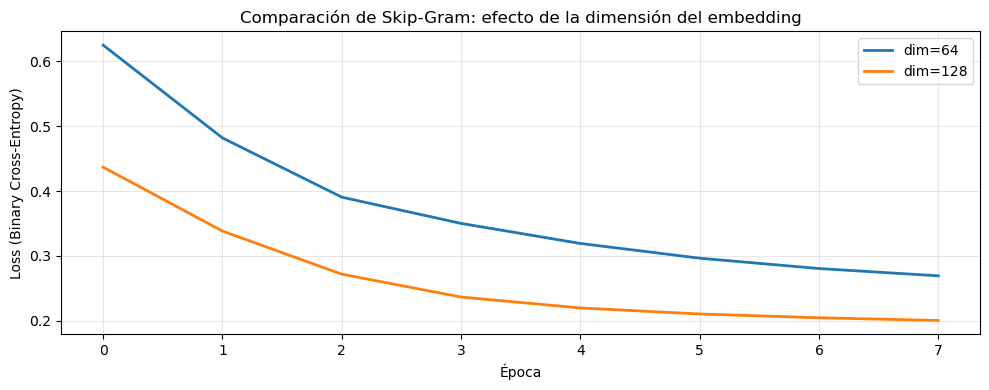

In [13]:
# Comparar curvas de loss de ambos modelos
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hist_64.history['loss'],  label=f'dim={EMB_DIM_1}', linewidth=2)
ax.plot(hist_128.history['loss'], label=f'dim={EMB_DIM_2}', linewidth=2)
ax.set_xlabel('Época')
ax.set_ylabel('Loss (Binary Cross-Entropy)')
ax.set_title('Comparación de Skip-Gram: efecto de la dimensión del embedding')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Extraer la matriz de embeddings

Los pesos de la capa `embedding` son nuestra **tabla de embeddings aprendida**.
Cada fila es el vector de una palabra.


In [14]:
# Extraer matrices de embeddings de ambos modelos
emb_matrix_64  = modelo_sg_64.get_layer('embedding').get_weights()[0]
emb_matrix_128 = modelo_sg_128.get_layer('embedding').get_weights()[0]

print(f'Matriz de embeddings (dim=64):  {emb_matrix_64.shape}')
print(f'Matriz de embeddings (dim=128): {emb_matrix_128.shape}')
print(f'  → {emb_matrix_64.shape[0]} palabras × {emb_matrix_64.shape[1]} dimensiones')


Matriz de embeddings (dim=64):  (7772, 64)
Matriz de embeddings (dim=128): (7772, 128)
  → 7772 palabras × 64 dimensiones


> **Preguntas para el alumno:**
> 1. ¿Cuál de los dos modelos tiene menor loss final? ¿Significa que es "mejor"?
> 2. ¿Qué pasaría si usaras `embedding_dim=8`? ¿Y `embedding_dim=300`?
> 3. ¿Por qué necesitamos negative sampling? ¿Qué predecería el modelo sin él?


# PARTE 3 — Clasificación de texto con LSTM y GRU

## 3.1 Padding: secuencias de longitud fija

Las redes recurrentes procesan secuencias token a token, pero
Keras necesita que todos los ejemplos de un batch tengan la **misma longitud**.

`pad_sequences` rellena con ceros (o trunca) cada secuencia a `MAX_LEN` tokens.

> **Regla práctica:** `MAX_LEN` debe cubrir la mayoría de los documentos
> sin ser excesivo. Valores típicos: percentil 90-95 de las longitudes.


In [15]:
# Elegir MAX_LEN basado en la distribución de longitudes
longitudes = [len(s) for s in sec_train]
MAX_LEN = int(np.percentile(longitudes, 90))  # cubre el 90% de los docs
MAX_LEN = min(MAX_LEN, 200)  # tope máximo para velocidad

print(f'MAX_LEN elegido: {MAX_LEN}')
print(f'  Media de tokens por documento: {np.mean(longitudes):.0f}')
print(f'  Percentil 50: {np.percentile(longitudes, 50):.0f}')
print(f'  Percentil 90: {np.percentile(longitudes, 90):.0f}')
print(f'  Máximo:       {max(longitudes)}')

# Aplicar padding a train, val y test
X_tr  = pad_sequences(sec_train, maxlen=MAX_LEN, padding='post', truncating='post')
X_val = pad_sequences(sec_val,   maxlen=MAX_LEN, padding='post', truncating='post')
X_te  = pad_sequences(secuencias_test, maxlen=MAX_LEN, padding='post', truncating='post')

# One-hot para las etiquetas
y_tr_cat  = to_categorical(y_tr,        NUM_CLASSES)
y_val_cat = to_categorical(y_val,       NUM_CLASSES)
y_te_cat  = to_categorical(y_test_raw,  NUM_CLASSES)

print(f'\nShapes resultantes:')
print(f'  X_tr:  {X_tr.shape}   y_tr:  {y_tr_cat.shape}')
print(f'  X_val: {X_val.shape}  y_val: {y_val_cat.shape}')
print(f'  X_te:  {X_te.shape}   y_te:  {y_te_cat.shape}')


MAX_LEN elegido: 200
  Media de tokens por documento: 219
  Percentil 50: 79
  Percentil 90: 399
  Máximo:       11420

Shapes resultantes:
  X_tr:  (1870, 200)   y_tr:  (1870, 4)
  X_val: (468, 200)  y_val: (468, 4)
  X_te:  (1556, 200)   y_te:  (1556, 4)


## 3.2 Cargar embeddings pre-entrenados en la capa Embedding

Usamos la matriz de embeddings aprendida por Skip-Gram en la Parte 2.
Al fijar `trainable=False`, los pesos del embedding **no cambian** durante
el entrenamiento del clasificador — el modelo solo aprende las capas superiores.

**¿Por qué hacer esto?**
- Los embeddings ya capturan semántica del corpus
- Reduce el riesgo de sobreajuste (menos parámetros que entrenar)
- El entrenamiento es más rápido

> **Alternativa:** Con `trainable=True`, el modelo puede ajustar los embeddings
> durante la clasificación. Esto puede mejorar o empeorar según el caso.


## 3.3 LSTM vs GRU — diferencias clave

| | **LSTM** | **GRU** |
|-|----------|---------|
| Puertas | 3 (olvido, entrada, salida) | 2 (actualización, reinicio) |
| Parámetros | ~4× embedding_dim × units | ~3× embedding_dim × units |
| Velocidad | Más lento | Más rápido |
| Memoria larga | Mejor (celda de memoria separada) | Bueno (pero sin celda separada) |
| ¿Cuándo usar? | Textos largos, dependencias complejas | Alternativa eficiente a LSTM |

### ¿Qué es `return_sequences=True`?

- `return_sequences=False` (por defecto): devuelve **solo el último** estado oculto → forma `(batch, units)`
- `return_sequences=True`: devuelve **todos** los estados → forma `(batch, timesteps, units)`

> Se usa `return_sequences=True` cuando se apilan **varias capas recurrentes**:
> la segunda capa necesita recibir una secuencia completa, no un solo vector.


In [16]:
def construir_clasificador(arch, emb_matrix, num_layers, lr, max_len, num_classes):
    """
    Construye un clasificador de texto con capa recurrente (LSTM o GRU).

    Parámetros:
        arch        : 'LSTM' o 'GRU'
        emb_matrix  : matriz de embeddings pre-entrenada (vocab_size, emb_dim)
        num_layers  : 1 o 2 capas recurrentes
        lr          : learning rate del optimizador Adam
        max_len     : longitud máxima de las secuencias
        num_classes : número de categorías de salida
    """
    vocab_size, emb_dim = emb_matrix.shape
    UNITS = 64  # unidades de la capa recurrente (reducido para velocidad)

    # Seleccionar tipo de capa recurrente
    RecurrentLayer = layers.LSTM if arch == 'LSTM' else layers.GRU

    modelo = keras.Sequential(name=f'{arch}_{num_layers}L_lr{lr}')

    # Capa Embedding con pesos pre-entrenados
    modelo.add(layers.Embedding(
        input_dim=vocab_size, output_dim=emb_dim,
        weights=[emb_matrix], trainable=False,
        input_length=max_len, mask_zero=True
    ))

    # Capas recurrentes
    if num_layers == 2:
        modelo.add(RecurrentLayer(UNITS, return_sequences=True))  # devuelve secuencia
        modelo.add(RecurrentLayer(UNITS))  # última capa: solo último estado
    else:
        modelo.add(RecurrentLayer(UNITS))

    # Capas densas de clasificación
    modelo.add(layers.Dense(64, activation='relu'))
    modelo.add(layers.Dropout(0.3))
    modelo.add(layers.Dense(num_classes, activation='softmax'))

    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return modelo


## 3.4 Experimento de hiperparámetros

Probamos combinaciones de:
- **Arquitectura:** LSTM vs GRU
- **Embedding:** dim=64 vs dim=128 (entrenados en Parte 2)
- **Capas recurrentes:** 1 vs 2
- **Learning rate:** 0.001 vs 0.003

Esto nos permite comparar qué configuración funciona mejor para este corpus.


In [17]:
# Configuraciones a probar
CONFIGS = [
    ('LSTM', emb_matrix_64,  1, 0.001, f'LSTM_d64_1L_lr001'),
    ('GRU',  emb_matrix_64,  1, 0.001, f'GRU_d64_1L_lr001'),
    ('LSTM', emb_matrix_128, 1, 0.001, f'LSTM_d128_1L_lr001'),
    ('LSTM', emb_matrix_64,  2, 0.001, f'LSTM_d64_2L_lr001'),
    ('LSTM', emb_matrix_64,  1, 0.003, f'LSTM_d64_1L_lr003'),
    ('GRU',  emb_matrix_128, 2, 0.003, f'GRU_d128_2L_lr003'),
]

EPOCHS_CLF = 8
BATCH_CLF  = 64

resultados = {}
mejor_acc  = 0
mejor_nombre = ''
mejor_modelo = None

for arch, emb_mat, n_layers, lr, nombre in CONFIGS:
    print(f'\n{"="*60}')
    print(f'Entrenando: {nombre}')
    print(f'  arch={arch}, emb_dim={emb_mat.shape[1]}, capas={n_layers}, lr={lr}')

    modelo = construir_clasificador(arch, emb_mat, n_layers, lr, MAX_LEN, NUM_CLASSES)

    hist = modelo.fit(
        X_tr, y_tr_cat,
        validation_data=(X_val, y_val_cat),
        epochs=EPOCHS_CLF, batch_size=BATCH_CLF, verbose=0
    )

    val_acc_final = hist.history['val_accuracy'][-1]
    print(f'  → val_accuracy final: {val_acc_final:.4f}')

    resultados[nombre] = hist.history

    if val_acc_final > mejor_acc:
        mejor_acc = val_acc_final
        mejor_nombre = nombre
        mejor_modelo = modelo

print(f'\n{"="*60}')
print(f'Mejor modelo: {mejor_nombre} (val_acc={mejor_acc:.4f})')



Entrenando: LSTM_d64_1L_lr001
  arch=LSTM, emb_dim=64, capas=1, lr=0.001
  → val_accuracy final: 0.2991

Entrenando: GRU_d64_1L_lr001
  arch=GRU, emb_dim=64, capas=1, lr=0.001
  → val_accuracy final: 0.3397

Entrenando: LSTM_d128_1L_lr001
  arch=LSTM, emb_dim=128, capas=1, lr=0.001
  → val_accuracy final: 0.6709

Entrenando: LSTM_d64_2L_lr001
  arch=LSTM, emb_dim=64, capas=2, lr=0.001
  → val_accuracy final: 0.2756

Entrenando: LSTM_d64_1L_lr003
  arch=LSTM, emb_dim=64, capas=1, lr=0.003
  → val_accuracy final: 0.3184

Entrenando: GRU_d128_2L_lr003
  arch=GRU, emb_dim=128, capas=2, lr=0.003
  → val_accuracy final: 0.7799

Mejor modelo: GRU_d128_2L_lr003 (val_acc=0.7799)


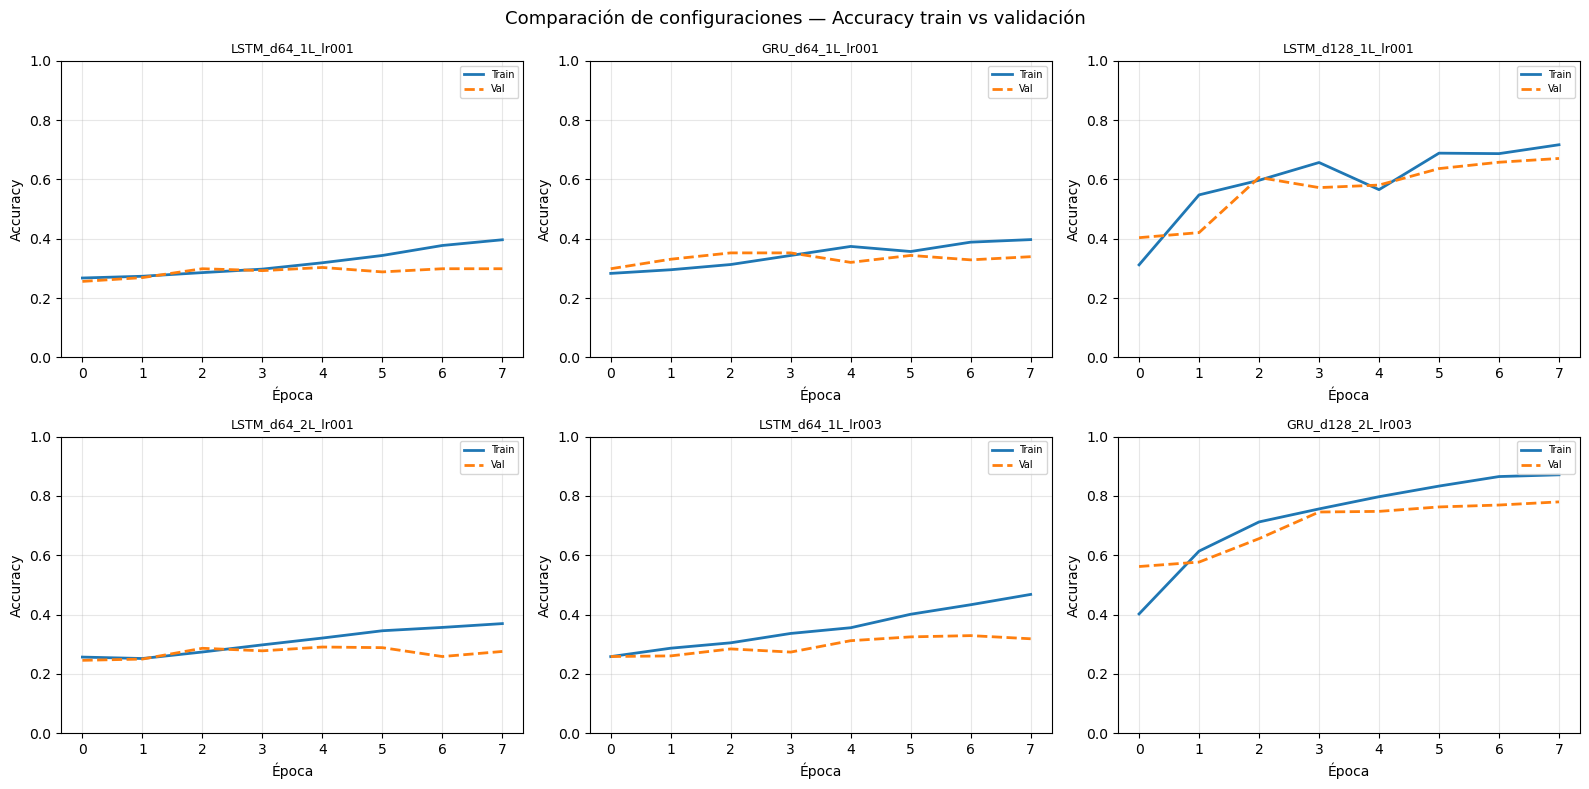

In [18]:
# Gráficas de accuracy train vs val para cada configuración
n_configs = len(resultados)
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for idx, (nombre, hist) in enumerate(resultados.items()):
    ax = axes[idx]
    ax.plot(hist['accuracy'],     label='Train', linewidth=2)
    ax.plot(hist['val_accuracy'], label='Val',   linewidth=2, linestyle='--')
    ax.set_title(nombre, fontsize=9)
    ax.set_xlabel('Época')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

# Ocultar ejes sobrantes si hay menos de 6 configs
for idx in range(n_configs, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Comparación de configuraciones — Accuracy train vs validación', fontsize=13)
plt.tight_layout()
plt.show()


> **Preguntas:**
> 1. ¿Cuál es el mejor modelo según la accuracy de validación?
> 2. ¿Algún modelo muestra signos de **sobreajuste** (train sube pero val baja)?
> 3. ¿GRU o LSTM es mejor en este caso? ¿Es siempre así?
> 4. ¿Qué efecto tiene usar 2 capas recurrentes vs 1?
> 5. ¿Un learning rate mayor siempre es mejor o peor?


# PARTE 4 — Evaluación con el mejor modelo

## 4.1 Test set personalizado

Creamos 10 frases de ejemplo escritas a mano para probar el modelo
en textos que nunca ha visto. Cada frase debería pertenecer claramente
a una de las 4 categorías:


In [19]:
# Test set personalizado: 10 frases con etiqueta esperada
test_custom = [
    ("nasa launched a new satellite to explore mars surface", 0),       # sci.space
    ("the spacecraft will orbit jupiter for two years", 0),              # sci.space
    ("the pitcher threw a fastball and struck out the batter", 1),       # baseball
    ("the team won the championship game in the ninth inning", 1),       # baseball
    ("the new graphics card renders images much faster", 2),             # comp.graphics
    ("opengl and directx are used for rendering scenes", 2),             # comp.graphics
    ("the conflict in the region escalated with military action", 3),    # politics
    ("peace negotiations between the countries failed again", 3),        # politics
    ("the astronaut conducted experiments aboard the station", 0),       # sci.space
    ("the batter hit a home run in the bottom of the seventh", 1),       # baseball
]

textos_custom   = [t for t, _ in test_custom]
labels_custom   = [l for _, l in test_custom]

# Preprocesar igual que el corpus
tokens_custom = [tokenizar(limpiar_texto(t)) for t in textos_custom]
seqs_custom   = [texto_a_ids(toks, word2idx) for toks in tokens_custom]
X_custom      = pad_sequences(seqs_custom, maxlen=MAX_LEN, padding='post', truncating='post')

print('Frases de test personalizadas:')
for i, (txt, lbl) in enumerate(test_custom):
    print(f'  [{i}] ({CATEGORIAS[lbl]:<30}) {txt[:60]}')


Frases de test personalizadas:
  [0] (sci.space                     ) nasa launched a new satellite to explore mars surface
  [1] (sci.space                     ) the spacecraft will orbit jupiter for two years
  [2] (rec.sport.baseball            ) the pitcher threw a fastball and struck out the batter
  [3] (rec.sport.baseball            ) the team won the championship game in the ninth inning
  [4] (comp.graphics                 ) the new graphics card renders images much faster
  [5] (comp.graphics                 ) opengl and directx are used for rendering scenes
  [6] (talk.politics.mideast         ) the conflict in the region escalated with military action
  [7] (talk.politics.mideast         ) peace negotiations between the countries failed again
  [8] (sci.space                     ) the astronaut conducted experiments aboard the station
  [9] (rec.sport.baseball            ) the batter hit a home run in the bottom of the seventh


In [20]:
# Predecir con el mejor modelo
preds_proba = mejor_modelo.predict(X_custom, verbose=0)
preds_clase = preds_proba.argmax(axis=1)

print(f'Modelo usado: {mejor_nombre}\n')
print(f'  {"Texto":<55} {"Real":<25} {"Predicho":<25} OK?')
print('  ' + '-'*110)
aciertos = 0
for i, (txt, lbl_real) in enumerate(test_custom):
    lbl_pred = preds_clase[i]
    ok = '✓' if lbl_pred == lbl_real else '✗'
    if lbl_pred == lbl_real:
        aciertos += 1
    print(f'  {txt[:53]:<55} {CATEGORIAS[lbl_real]:<25} {CATEGORIAS[lbl_pred]:<25} {ok}')

print(f'\nAccuracy en test personalizado: {aciertos}/{len(test_custom)} = {aciertos/len(test_custom):.0%}')


Modelo usado: GRU_d128_2L_lr003

  Texto                                                   Real                      Predicho                  OK?
  --------------------------------------------------------------------------------------------------------------
  nasa launched a new satellite to explore mars surface   sci.space                 comp.graphics             ✗
  the spacecraft will orbit jupiter for two years         sci.space                 comp.graphics             ✗
  the pitcher threw a fastball and struck out the batte   rec.sport.baseball        rec.sport.baseball        ✓
  the team won the championship game in the ninth innin   rec.sport.baseball        rec.sport.baseball        ✓
  the new graphics card renders images much faster        comp.graphics             sci.space                 ✗
  opengl and directx are used for rendering scenes        comp.graphics             comp.graphics             ✓
  the conflict in the region escalated with military ac   talk.polit

## 4.2 Matriz de confusión — test set oficial

La matriz de confusión muestra **qué categorías confunde el modelo**.
La diagonal muestra los aciertos; fuera de la diagonal están los errores.

**Cómo interpretar:**
- Una fila con muchos valores fuera de la diagonal → esa categoría es difícil de predecir
- Una columna con muchos valores fuera de la diagonal → el modelo predice esa categoría cuando no debería


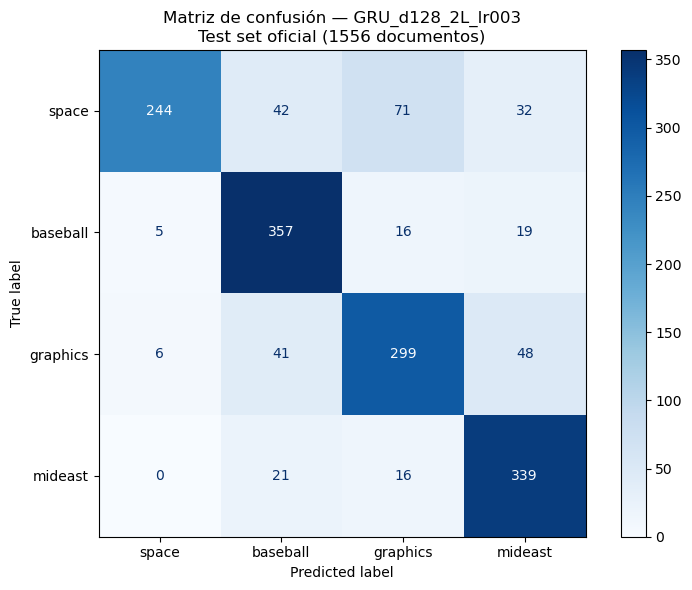


Classification Report:
              precision    recall  f1-score   support

       space       0.96      0.63      0.76       389
    baseball       0.77      0.90      0.83       397
    graphics       0.74      0.76      0.75       394
     mideast       0.77      0.90      0.83       376

    accuracy                           0.80      1556
   macro avg       0.81      0.80      0.79      1556
weighted avg       0.81      0.80      0.79      1556



In [21]:
# Predicción sobre el test set oficial (no el personalizado)
preds_test = mejor_modelo.predict(X_te, verbose=0).argmax(axis=1)

# Matriz de confusión
cm = confusion_matrix(y_test_raw, preds_test)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(cm, display_labels=[c.split('.')[-1] for c in CATEGORIAS])
disp.plot(cmap='Blues', ax=ax, values_format='d')
ax.set_title(f'Matriz de confusión — {mejor_nombre}\n'
             f'Test set oficial ({len(y_test_raw)} documentos)', fontsize=12)
plt.tight_layout()
plt.show()

# Classification report
print('\nClassification Report:')
print(classification_report(y_test_raw, preds_test,
      target_names=[c.split('.')[-1] for c in CATEGORIAS]))


> **Preguntas:**
> 1. ¿Cuál es la categoría con **peor** precision? ¿Por qué crees que ocurre?
> 2. ¿Qué par de categorías se confunden más entre sí?
> 3. ¿La accuracy del test personalizado coincide con la del test oficial?
> 4. Si quisieras mejorar el modelo, ¿qué cambiarías primero:
>    el preprocesamiento, los embeddings, la arquitectura o los hiperparámetros?


## Resumen

| Parte | Qué hicimos | Herramienta clave |
|-------|-------------|-------------------|
| 1 | Limpiar y tokenizar texto; construir vocabulario | `re`, `collections`, `train_test_split` |
| 2 | Entrenar embeddings Skip-Gram desde cero | `Embedding`, `Dot`, `Dense(sigmoid)` |
| 3 | Clasificar texto con LSTM y GRU | `LSTM`, `GRU`, `pad_sequences` |
| 4 | Evaluar con matriz de confusión | `ConfusionMatrixDisplay` |

**Próximo paso:** Aprende a aplicar esta metodología en tus propios proyectos de clasificación de texto.